In [194]:
import random
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
from transformers import RobertaConfig, RobertaForMaskedLM
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd

device = torch.device("mps")

BATCH_SIZE = 128
LR = 5e-5
EPOCHS = 20

# Create Tokenizer 

In [195]:
vocab = json.load(open("vocab.json", "r"))
tokenizer = Tokenizer(models.WordLevel(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.WordLevelTrainer(
    min_frequency=1, special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)
tokenizer.train_from_iterator(vocab, trainer)

tokenizer.save("opcode_tokenizer.json")

In [196]:
files = os.listdir(
    "/Volumes/New Volume/malware-detection-dataset/opcodes/processed_data"
)
files = [
    os.path.join(
        "/Volumes/New Volume/malware-detection-dataset/opcodes/processed_data", file
    )
    for file in files
    if not file.startswith("._")
]

sequences = []

for file in files:
    data = json.load(open(file, "r"))
    sequences.append(data)

sequences = np.array(sequences).reshape(-1, 64)

# Tokenize Data

In [197]:
tokenized_sequences = np.zeros_like(sequences, dtype=np.int64)
for i, sequence in enumerate(tqdm(sequences, desc="Tokenizing")):
    tokens = tokenizer.encode(" ".join(sequence)).ids
    if len(tokens) > 64:
        continue
    else:
        tokenized_sequences[i] = tokens

tokenized_sequences.shape

Tokenizing: 100%|██████████| 97860/97860 [00:05<00:00, 16901.79it/s]


(97860, 64)

# Create Dataset

In [ ]:
class OpcodeDataset(Dataset):
    def __init__(self, tokenized_sequences, vocab_size: int, mask_prob: float = 0.2):
        self.sequences = tokenized_sequences
        self.mask_prob = mask_prob
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        tokens = self.sequences[idx].copy()

        input_tokens = np.array(tokens, dtype=np.int64)
        labels = np.full_like(input_tokens, -100)
        attention_mask = np.full_like(input_tokens, 1)
        attention_mask[input_tokens == 0] = 0

        for i, token in enumerate(input_tokens):
            if np.random.random() < 0.15:
                labels[i] = token
                sample = np.random.random()
                if sample < 0.8:
                    input_tokens[i] = 4
                elif 0.8 < sample < 0.9:
                    input_tokens[i] = np.random.randint(0, self.vocab_size)
        return {"input_ids": input_tokens, "attention_mask": attention_mask}, labels


train_sequences, test_sequences = train_test_split(tokenized_sequences)
# del tokenized_sequences
train = OpcodeDataset(train_sequences, tokenizer.get_vocab_size())
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
test = OpcodeDataset(test_sequences, tokenizer.get_vocab_size())
test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
input, labels = train[np.random.randint(len(train))]
print(f"Masked tokens at {np.argwhere(labels != -100).T[0]}")

pd.DataFrame(
    {
        "Tokens": input["input_ids"],
        "Opcode": tokenizer.decode(input["input_ids"], skip_special_tokens=False).split(
            " "
        ),
        "Mask": input["attention_mask"],
        "Labels": labels,
    }
).transpose()

Masked tokens at [ 6 23 29 32 39 43 44 48 62]

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Tokens,1237,1206,643,2394,1144,643,941,1206,974,1623,...,138,33,927,1206,1206,138,33,927,4,974
Opcode,ret,push,inc,xor,pop,inc,lodsq,push,mov,sub,...,call,add,lea,push,push,call,add,lea,[MASK],mov
Labels,-100,-100,-100,-100,-100,-100,2394,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,1206,-100


# Create Model

In [201]:
config = RobertaConfig(
    vocab_size=tokenizer.get_vocab_size(),
    max_position_embeddings=512,
    num_attention_heads=6,
    num_hidden_layers=3,
    type_vocab_size=1,
    hidden_size=252,
    intermediate_size=512,
)

model = RobertaForMaskedLM(config)
model.to(device)

RobertaForMaskedLM(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(2414, 252, padding_idx=1)
      (position_embeddings): Embedding(512, 252, padding_idx=1)
      (token_type_embeddings): Embedding(1, 252)
      (LayerNorm): LayerNorm((252,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-2): 3 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=252, out_features=252, bias=True)
              (key): Linear(in_features=252, out_features=252, bias=True)
              (value): Linear(in_features=252, out_features=252, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=252, out_features=252, bias=True)
              (LayerNorm):

# Train Model

In [202]:
def test(model, test_loader):
    model.eval()
    test_loss = 0.0

    test_loop = tqdm(
        test_loader, desc=f"Test Epoch {epoch + 1}/{EPOCHS}", leave=False, unit="batch"
    )

    for tokens, labels in test_loop:
        tokens = tokens.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            output = model(tokens, labels=labels)

        test_loss += output.loss.item()
    model.train()
    return test_loss / len(test_loader)


optimizer = AdamW(model.parameters(), lr=LR)
losses = []
test_losses = []

for epoch in range(EPOCHS):
    test_losses.append(test(model, test_loader))
    train_loop = tqdm(
        train_loader,
        desc=f"Train Epoch {epoch + 1}/{EPOCHS}",
        unit="batch",
        leave=False,
    )
    for input, labels in train_loop:
        input_ids, attention_mask = input.values()
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(input_ids, attention_mask, labels=labels)
        loss = output.loss
        loss.backward()
        optimizer.step()
        train_loop.set_postfix_str(
            f"Loss: {loss.item():.2f}, Test Loss: {test_losses[-1]:.2f}"
        )
        losses.append(loss.item())

Test Epoch 1/20:  53%|█████▎    | 102/192 [00:10<00:02, 42.75batch/s]We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


In [204]:
model.save_pretrained("opcode-bert")

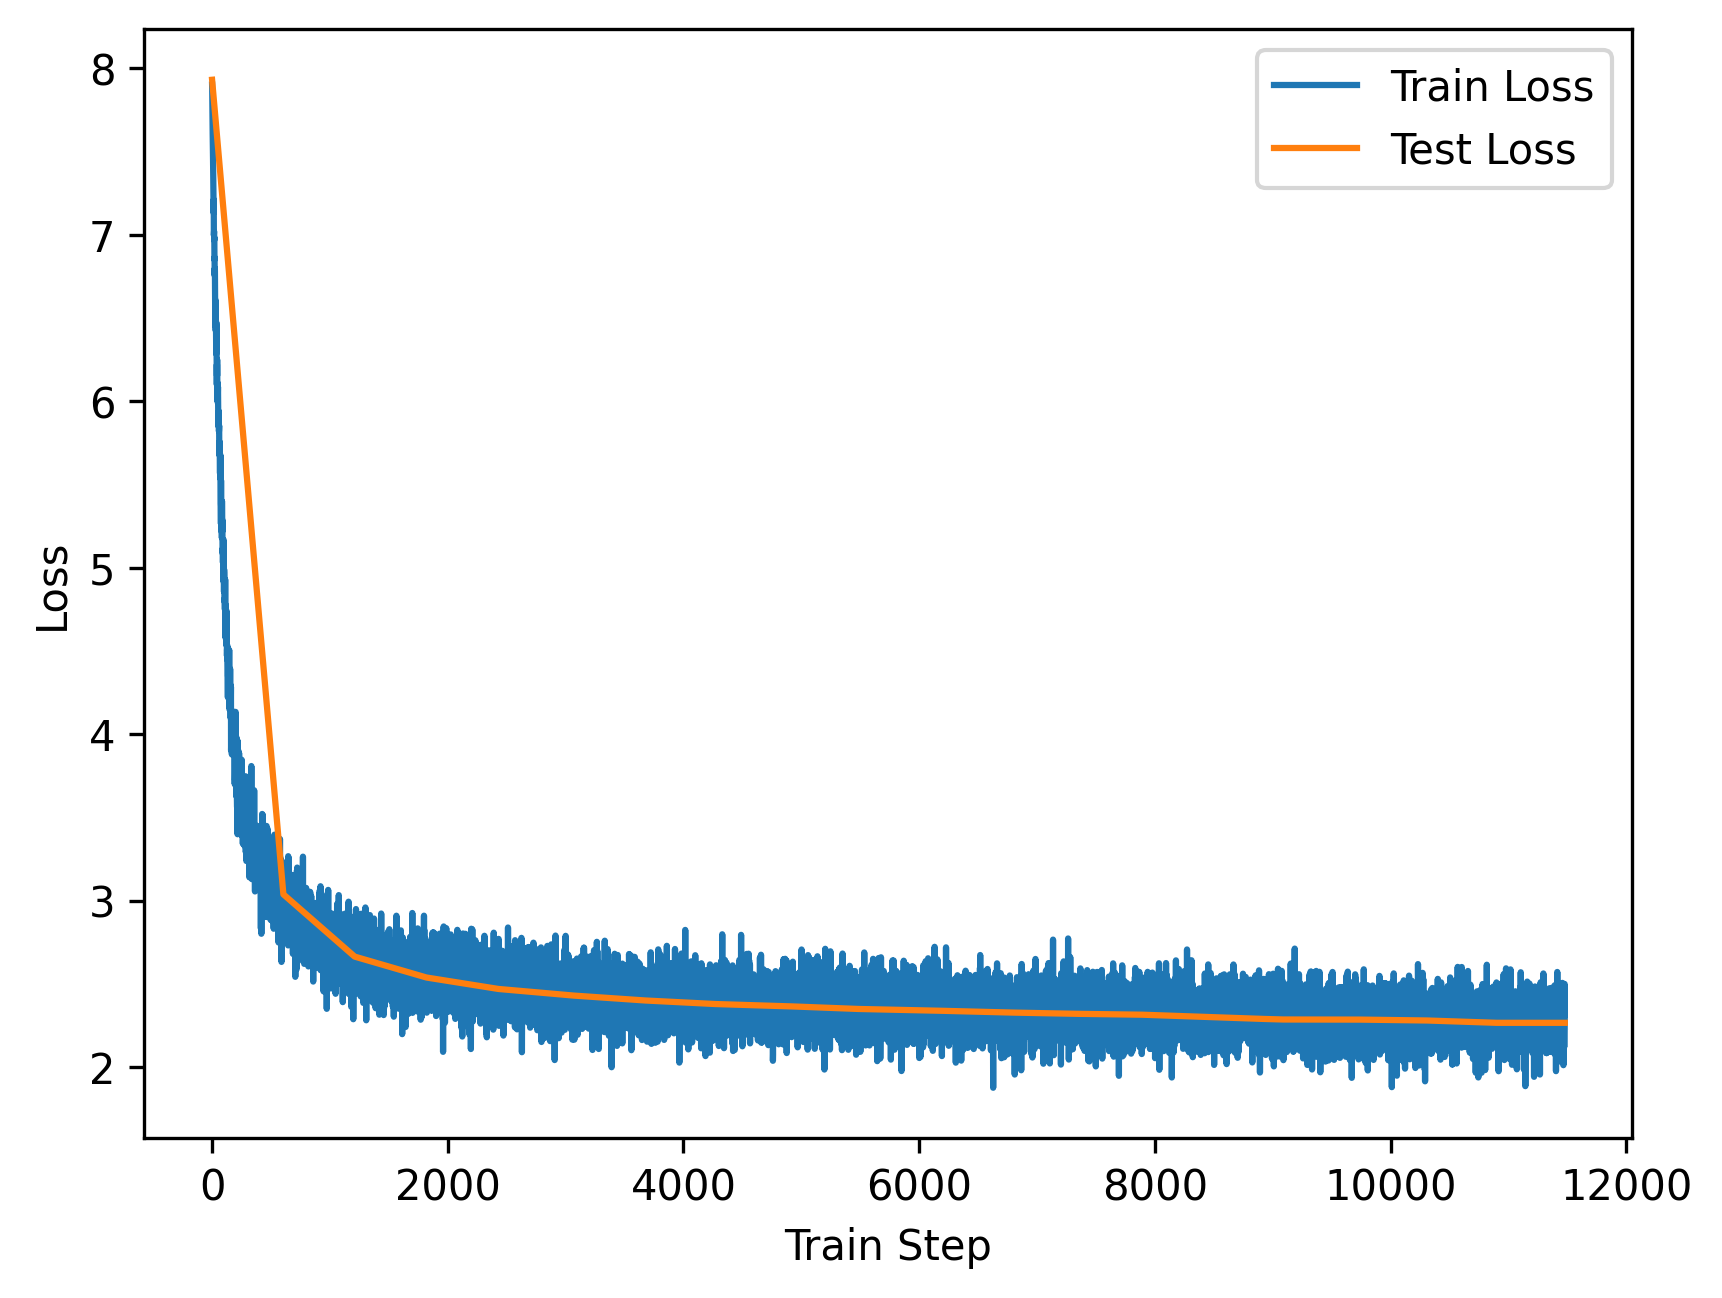

In [203]:
losses = np.array(losses)
test_losses = np.array(test_losses)

test_loss_steps = np.linspace(0, len(losses) - 1, num=len(test_losses))
test_loss_interpolated = np.interp(np.arange(len(losses)), test_loss_steps, test_losses)

plt.figure(dpi=300)
plt.plot(losses, label="Train Loss")
plt.plot(test_loss_interpolated, label="Test Loss")
plt.legend()
plt.xlabel("Train Step")
plt.ylabel("Loss")
plt.show()

In [355]:
model = RobertaForMaskedLM.from_pretrained("./opcode-bert")
tokenizer = Tokenizer.from_file("./opcode_tokenizer.json")
model = model.to(device)

test_loop = tqdm(test_loader, desc="Evaluation", leave=False, unit="batch")

actual = []
predicted = []
was_masked = []
for tokens, labels in test_loop:
    tokens = tokens.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        output = model(tokens, labels=labels)

    tokens = tokens.cpu()
    labels = labels.cpu()
    output = output.logits.cpu()

    gt = np.zeros_like(labels)
    gt[labels == -100] = tokens[labels == -100]
    gt[labels != -100] = labels[labels != -100]
    mask = labels != -100

    actual.append(gt)
    predicted.append(output.argmax(dim=-1))
    was_masked.append(mask)

In [356]:
actual = np.array([gt for batch in actual for gt in batch])
predicted = np.array([pred for batch in predicted for pred in batch])
was_masked = np.array([mask for batch in was_masked for mask in batch])

actual.shape == predicted.shape

True

In [1]:
idx = np.random.randint(len(actual))

df = pd.DataFrame(
    {
        ("Actual", "ID"): actual[idx],
        ("Actual", "Token"): tokenizer.decode(
            actual[idx], skip_special_tokens=False
        ).split(" "),
        ("Predicted", "ID"): predicted[idx],
        ("Predicted", "Token"): tokenizer.decode(
            predicted[idx], skip_special_tokens=False
        ).split(" "),
        ("Classification", "Correct"): (actual[idx] == predicted[idx]),
        ("Classification", "Masked"): was_masked[idx],
        ("Classification", "Correctly Guessed"): (actual[idx] == predicted[idx])
        & was_masked[idx],
    }
)

df.columns = pd.MultiIndex.from_tuples(df.columns)
print(
    np.count_nonzero(df["Classification", "Correctly Guessed"])
    / np.count_nonzero(df["Classification", "Masked"])
)
df

NameError: name 'actual' is not defined

In [ ]:
sum(
    [
        np.count_nonzero((y == y_hat) & mask) / np.count_nonzero(mask)
        for y, y_hat, mask in zip(actual, predicted, was_masked)
    ]
) / len(actual)

0.46882742308527653